# Cost analysis
What does it cost to pay for the hours, counted the client's way and counted our way? Overtime is paid at 1.5x and Sunday and public-holiday work at 2x on top of the hourly rate, so where an hour is counted (which week, which day, which person) changes the money.

**Pay rule used here.** An hour is paid at 2x on a Sunday or public holiday. Otherwise it is paid at 1.5x once the person's running total for the week passes 45 hours, and at 1x before that. Sunday and holiday hours still count toward the 45. There is no tripling. Hours are taken in time order. Pay = hours x multiplier x that employee ID's hourly rate.

**Two ways of counting.**
- **A. The client's way** (`weekly_summary.csv` plus the shifts): weeks and days by clock-in date, one row per employee ID, no merging of duplicate IDs, missing clock-outs count as 0.
  - **A0** prices the summary alone: summary hours at 1x and summary overtime hours at 1.5x. The summary has no day detail, so it has no Sunday or holiday premium.
  - **A1** takes the summary's hours and uses the shifts to find which hours fall on a Sunday or public holiday (by clock-in date), then applies the pay rule.
- **B. Our way:** the greater-portion rule (a shift that crosses midnight goes whole to the day holding most of it, which sets the week and the Sunday/holiday rate). Our system also detects fraud before pay, so it **removes duplicate people** (every employee ID of a person sharing an ID number, bank account or tax number is held for escalation and not paid) **removes the second site on a day** (a person cannot work at two different sites on the same day, so only the site with the most hours that day is paid and the hours at the other site are removed), and **removes overlapping time** (when one person has two shifts at the same time at the same site, the overlapping hours are paid once, not twice).

Only complete weeks are used (the in-progress week is only part worked). This notebook reads the hourly rate from `payroll_details.csv` (only `employee_id` and `hourly_rate`, never bank or tax numbers) and shows it in the tables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.loader import load_shifts, load_holidays
from src.hours import parse_shifts, attribute_hours, data_cutoff
from src.integrity import find_duplicate_people, add_person_key
from src.loader import load_payroll

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)

shifts_raw = load_shifts("data/shifts.csv")
holidays = load_holidays("data/public_holidays.csv")
employees = pd.read_csv("data/employees.csv")
summary = pd.read_csv("data/weekly_summary.csv", parse_dates=["week_starting"])
rates = pd.read_csv("data/payroll_details.csv", usecols=["employee_id", "hourly_rate"]).set_index("employee_id")["hourly_rate"]

shifts = parse_shifts(shifts_raw)
cutoff = data_cutoff(shifts)
current_week = cutoff - pd.Timedelta(days=cutoff.weekday())
people = find_duplicate_people(employees, load_payroll("data/payroll_details.csv"))   # same people as the model uses
holiday_dates = set(pd.to_datetime(holidays["date"]))
name = employees.set_index("employee_id")["full_name"]

print("complete weeks: before", current_week.date(), "| employee IDs with a rate:", rates.notna().sum(), "of", len(employees))
print("missing or non-positive rates:", int((rates.reindex(employees.employee_id).isna() | (rates.reindex(employees.employee_id) <= 0)).sum()))
print("rate range:", rates.min(), "to", rates.max(), "| median", rates.median())

complete weeks: before 2026-08-10 | employee IDs with a rate: 213 of 213
missing or non-positive rates: 0
rate range: 28.41 to 59.52 | median 34.83


## 1. The pricing function
Takes one row per worked segment with a person, week, time order, hours, whether it is a Sunday or holiday, and the employee ID's rate. It returns the same rows with how many hours were paid at 1x, 1.5x and 2x, and the money.

In [2]:
def price_hours(df):
    """df columns: person, week_start, order, employee_id, hours, premium_day (Sunday/holiday), rate."""
    d = df.sort_values(["person", "week_start", "order"]).copy()
    g = d.groupby(["person", "week_start"])["hours"]
    d["cum_before"] = g.cumsum() - d["hours"]
    d["cum_after"] = g.cumsum()
    normal = ~d["premium_day"]
    d["h_2x"] = d["hours"].where(d["premium_day"], 0.0)
    d["h_1x"] = np.clip(45 - d["cum_before"], 0, d["hours"]).where(normal, 0.0)
    d["h_15x"] = (d["hours"] - d["h_1x"]).where(normal, 0.0)
    d["base_pay"] = d["hours"] * d["rate"]
    d["ot_premium"] = 0.5 * d["h_15x"] * d["rate"]
    d["day_premium"] = 1.0 * d["h_2x"] * d["rate"]
    d["premium"] = d["ot_premium"] + d["day_premium"]
    d["pay"] = d["base_pay"] + d["premium"]
    over = np.clip(d["cum_after"] - 55, 0, d["hours"])                     # hours beyond the 55 cap
    d["h_over55"] = over
    d["cost_over55"] = over * d["rate"] * np.where(d["premium_day"], 2.0, 1.5)
    d["premium_over55"] = d["cost_over55"] - over * d["rate"]
    return d

# hand-made checks
def mk(rows):
    return pd.DataFrame(rows, columns=["person", "week_start", "order", "employee_id", "hours", "premium_day", "rate"])
w = pd.Timestamp("2026-01-05")
# 5 x 10h weekdays then a 10h Sunday, rate 100: 45h ordinary... 40h at 1x?  cumulative: 10,20,30,40,50 -> last weekday has 5h at 1x and 5h at 1.5x; Sunday 10h at 2x
t1 = price_hours(mk([("p", w, i, "E", 10, False, 100) for i in range(5)] + [("p", w, 5, "E", 10, True, 100)]))
assert t1.h_1x.sum() == 45 and t1.h_15x.sum() == 5 and t1.h_2x.sum() == 10
assert t1.pay.sum() == 45 * 100 + 5 * 150 + 10 * 200
assert np.isclose(t1.h_over55.sum(), 5) and np.isclose(t1.cost_over55.sum(), 5 * 200)   # last 5h of the 60h week were Sunday hours
# a holiday Monday counts toward the 45 but is paid 2x
t2 = price_hours(mk([("p", w, 0, "E", 9, True, 50), ("p", w, 1, "E", 9, False, 50)]))
assert t2.h_2x.sum() == 9 and t2.h_1x.sum() == 9 and t2.pay.sum() == 9 * 100 + 9 * 50
# two IDs of one person share the 45-hour threshold, each paid at its own rate
t3 = price_hours(mk([("p", w, 0, "E1", 30, False, 100), ("p", w, 1, "E2", 30, False, 60)]))
assert t3.h_1x.sum() == 45 and t3.h_15x.sum() == 15 and np.isclose(t3.pay.sum(), 30 * 100 + 15 * 60 + 15 * 90)
# hours always add up
for t in (t1, t2, t3):
    assert np.allclose(t.h_1x + t.h_15x + t.h_2x, t.hours)
print("pricing checks passed")

pricing checks passed


## 2. Method A: the client's way
Weeks and days by clock-in date, one row per employee ID. First check that this reproduces the client's `weekly_summary.csv`.

In [3]:
valid = shifts[~shifts.excluded]
a_seg = pd.DataFrame({
    "person": valid.employee_id, "employee_id": valid.employee_id,
    "week_start": valid.shift_date - pd.to_timedelta(valid.shift_date.dt.weekday, unit="D"),
    "order": valid.start, "hours": valid.duration_hours,
    "premium_day": (valid.shift_date.dt.weekday == 6) | valid.shift_date.isin(holiday_dates)})
a_seg["rate"] = a_seg.employee_id.map(rates)
a_seg = a_seg[a_seg.week_start < current_week]

recomputed = a_seg.groupby(["employee_id", "week_start"]).hours.sum()
s = summary[summary.week_starting < current_week].set_index(["employee_id", "week_starting"])
s.index = s.index.set_names(["employee_id", "week_start"])
joined = s.join(recomputed.rename("recomputed"), how="outer").fillna({"recomputed": 0, "total_hours": 0})
bad = (joined.total_hours - joined.recomputed).abs() > 0.01
print("ID-weeks in summary:", len(s), "| ID-weeks recomputed:", len(recomputed), "| mismatches:", int(bad.sum()))
assert not bad.any()
ot_check = (s.total_hours - 45).clip(lower=0)
print("overtime_hours = hours above 45 for every row:", bool(((ot_check - s.overtime_hours).abs() < 0.01).all()))

ID-weeks in summary: 1917 | ID-weeks recomputed: 1917 | mismatches: 0
overtime_hours = hours above 45 for every row: True


In [4]:
A1 = price_hours(a_seg)

# A0: the summary alone, no day detail
s0 = s.reset_index()
s0["rate"] = s0.employee_id.map(rates)
s0["base_pay"] = s0.total_hours * s0.rate
s0["ot_premium"] = 0.5 * s0.overtime_hours * s0.rate
s0["pay"] = s0.base_pay + s0.ot_premium
print("A0 (summary only) total:  R{:,.0f}".format(s0.pay.sum()))
print("A1 (summary + shift days): R{:,.0f}".format(A1.pay.sum()))

A0 (summary only) total:  R3,081,141
A1 (summary + shift days): R3,512,646


## 3. Method B: our way
Greater-portion attribution sets the week and the Sunday/holiday rate. Then three things our system would catch are taken out before pricing, one after another so each one's effect can be seen:
1. the **duplicate people** (all their employee IDs);
2. **two sites on one day**: if one employee ID has hours at two different sites on the same (attributed) day, only the site with the most hours is paid and the hours at the lower site are removed;
3. **overlapping time** that is left (shifts at the same site that run at the same time): the overlap is paid once.

In [5]:
segments = attribute_hours(shifts, holidays)
segments = add_person_key(segments, people)
start = shifts.set_index("shift_id")["start"]
segments["order"] = segments.shift_id.map(start)
# the second half of an exact tie starts at midnight of the attributed day
second = segments.duplicated("shift_id", keep="first")
segments.loc[second, "order"] = segments.loc[second, "attributed_date"]
segments = segments[segments.week_start < current_week].copy()
dup_ids = set(e for ids in people.employee_ids for e in ids)
segments["hours_before_overlap"] = segments["hours"]

# --- step 2: two sites on the same day. Keep the site with the most hours that day, drop the other site(s).
nd = segments[~segments.employee_id.isin(dup_ids)]
day_site = nd.groupby(["employee_id", "attributed_date", "site_id"]).hours.sum().rename("site_hours").reset_index()
day_site["n_sites"] = day_site.groupby(["employee_id", "attributed_date"]).site_id.transform("nunique")
day_site["rank"] = day_site.sort_values(["site_hours", "site_id"], ascending=[False, True]).groupby(["employee_id", "attributed_date"]).cumcount()
lower = day_site[(day_site.n_sites > 1) & (day_site["rank"] > 0)]
lower_key = set(zip(lower.employee_id, lower.attributed_date, lower.site_id))
segments["lower_site"] = [(e, d, st) in lower_key for e, d, st in zip(segments.employee_id, segments.attributed_date, segments.site_id)]
multi_days = day_site[day_site.n_sites > 1].groupby(["employee_id", "attributed_date"]).ngroups
print("person-days at two sites (not duplicate people):", multi_days, "| people:", day_site[day_site.n_sites > 1].employee_id.nunique(),
      "| hours at the lower site removed:", round(lower.site_hours.sum(), 1))

# --- step 3: overlapping time that is left, per employee ID (after steps 1 and 2)
kept = valid[valid.shift_id.isin(segments.loc[~segments.lower_site & ~segments.employee_id.isin(dup_ids), "shift_id"])]
v = kept[["shift_id", "employee_id", "start", "end", "duration_hours"]].sort_values(["employee_id", "start", "shift_id"]).copy()
v["prev_end"] = v.groupby("employee_id")["end"].transform(lambda x: x.cummax().shift())
paid_start = v[["start", "prev_end"]].max(axis=1)
v["paid_hours"] = ((v["end"] - paid_start).dt.total_seconds() / 3600).clip(lower=0, upper=v["duration_hours"])
v["overlap_hours"] = v["duration_hours"] - v["paid_hours"]
print("shifts with overlapping time left:", int((v.overlap_hours > 1e-9).sum()), "| overlap hours:", round(v.overlap_hours.sum(), 1))
cut = v.set_index("shift_id")["overlap_hours"]
segments["overlap"] = segments.shift_id.map(cut).fillna(0.0).where(~segments.duplicated("shift_id", keep="last"), 0.0)   # taken off the first part of a split shift
segments["hours_final"] = (segments["hours"] - segments["overlap"]).clip(lower=0)

def b_frame(seg, hours_col):
    d = pd.DataFrame({"employee_id": seg.employee_id, "person": seg.employee_id, "week_start": seg.week_start,
                      "order": seg.order, "hours": seg[hours_col], "premium_day": seg.is_sunday | seg.is_public_holiday})
    d["rate"] = d.employee_id.map(rates)
    return d

is_dup = segments.employee_id.isin(dup_ids)
step2 = price_hours(b_frame(segments, "hours_before_overlap"))                                       # greater-portion rule only
step3 = price_hours(b_frame(segments[~is_dup], "hours_before_overlap"))                              # + duplicate people removed
step4 = price_hours(b_frame(segments[~is_dup & ~segments.lower_site], "hours_before_overlap"))       # + lower site on a two-site day removed
B = price_hours(b_frame(segments[~is_dup & ~segments.lower_site], "hours_final"))                    # + overlapping time removed
print("B total: R{:,.0f}".format(B.pay.sum()))
print("duplicate people removed:", len(people), "people,", len(dup_ids), "employee IDs")

person-days at two sites (not duplicate people): 114 | people: 73 | hours at the lower site removed: 451.5
shifts with overlapping time left: 10 | overlap hours: 30.8
B total: R3,371,826
duplicate people removed: 5 people, 10 employee IDs


In [6]:
# where the hour difference between A and B comes from
moved_in = valid.assign(a_week=lambda x: x.shift_date - pd.to_timedelta(x.shift_date.dt.weekday, unit="D")).merge(
    attribute_hours(shifts, holidays)[["shift_id", "week_start"]].drop_duplicates("shift_id"), on="shift_id")
into_current = moved_in[(moved_in.a_week < current_week) & (moved_in.week_start >= current_week)]
dup_hours = step2[step2.employee_id.isin(dup_ids)].hours.sum()
site_hours = step3.hours.sum() - step4.hours.sum()
ovl_hours = step4.hours.sum() - B.hours.sum()
b_expected = A1.hours.sum() - into_current.duration_hours.sum() - dup_hours - site_hours - ovl_hours
print("A hours                                             ", round(A1.hours.sum(), 1))
print("- moved into the in-progress week (greater-portion):", round(into_current.duration_hours.sum(), 1))
print("- hours of the duplicate people removed             ", round(dup_hours, 1))
print("- hours at the lower site on two-site days removed  ", round(site_hours, 1))
print("- overlapping hours left and removed                ", round(ovl_hours, 1))
print("= B hours                                           ", round(b_expected, 1), "| actual B:", round(B.hours.sum(), 1))
assert abs(b_expected - B.hours.sum()) < 0.5

A hours                                              80619.2
- moved into the in-progress week (greater-portion): 122.8
- hours of the duplicate people removed              2560.5
- hours at the lower site on two-site days removed   451.5
- overlapping hours left and removed                 30.8
= B hours                                            77453.8 | actual B: 77453.8


## 4. Totals and where the difference comes from

In [7]:
def totals(name, d):
    return {"method": name, "hours": d.hours.sum(), "base pay (all 1x)": d.base_pay.sum(),
            "overtime premium": d.ot_premium.sum(), "Sunday/holiday premium": d.day_premium.sum(),
            "total cost": d.pay.sum()}

tot = pd.DataFrame([
    {"method": "A0 summary only", "hours": s0.total_hours.sum(), "base pay (all 1x)": s0.base_pay.sum(),
     "overtime premium": s0.ot_premium.sum(), "Sunday/holiday premium": 0.0, "total cost": s0.pay.sum()},
    totals("A1 summary + shift days", A1), totals("A1 + greater-portion rule", step2), totals("+ duplicate people removed", step3), totals("+ lower site on two-site days removed", step4), totals("B (+ overlapping time removed)", B)]).set_index("method")
tot["difference vs A1"] = tot["total cost"] - tot.loc["A1 summary + shift days", "total cost"]
display(tot.round(0))

for col in ["h_1x", "h_15x", "h_2x"]:
    print(col, "A1", round(A1[col].sum(), 1), "| B", round(B[col].sum(), 1))

,hours,base pay (all 1x),overtime premium,Sunday/holiday premium,total cost,difference vs A1
method,,,,,,
A0 summary only,80619.0,3032077.0,49064.0,0.0,3081141.0,-431505.0
A1 summary + shift days,80619.0,3032077.0,16685.0,463884.0,3512646.0,0.0
A1 + greater-portion rule,80496.0,3027841.0,19223.0,473750.0,3520814.0,8168.0
+ duplicate people removed,77936.0,2916428.0,19223.0,457335.0,3392986.0,-119660.0
+ lower site on two-site days removed,77484.0,2898813.0,17716.0,456581.0,3373110.0,-139536.0
B (+ overlapping time removed),77454.0,2897773.0,17562.0,456491.0,3371826.0,-140820.0


h_1x A1 67432.2 | B 64291.5
h_15x A1 884.0 | B 958.0
h_2x A1 12303.0 | B 12204.2


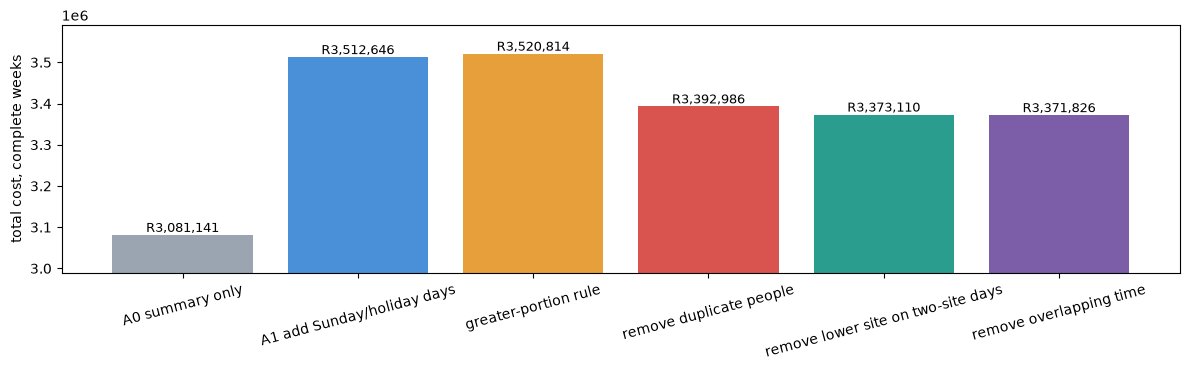

In [8]:
steps = [("A0 summary only", tot.loc["A0 summary only", "total cost"]),
         ("A1 add Sunday/holiday days", tot.loc["A1 summary + shift days", "total cost"]),
         ("greater-portion rule", tot.loc["A1 + greater-portion rule", "total cost"]),
         ("remove duplicate people", tot.loc["+ duplicate people removed", "total cost"]),
         ("remove lower site on two-site days", tot.loc["+ lower site on two-site days removed", "total cost"]),
         ("remove overlapping time", tot.loc["B (+ overlapping time removed)", "total cost"])]
vals = [v for _, v in steps]
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.bar([n for n, _ in steps], vals, color=["#9aa5b1", "#4a90d9", "#e69f3a", "#d9534f", "#2a9d8f", "#7b5ea7"])
for i, v in enumerate(vals):
    ax.text(i, v, "R{:,.0f}".format(v), ha="center", va="bottom", fontsize=9)
ax.set_ylim(min(vals) * 0.97, max(vals) * 1.02); ax.set_ylabel("total cost, complete weeks")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 5. Per employee: the client's way against ours
One row per employee ID over the complete weeks. `diff` is B minus A1, so a positive number means our counting costs more than the client's and a negative number means it costs less. The duplicate people are not paid in B, so their B cost is 0 and `diff` is the pay held back. The lower site on a two-site day is not paid either.

In [9]:
def per_id(d):
    return d.groupby("employee_id").agg(hours=("hours", "sum"), h_2x=("h_2x", "sum"), h_15x=("h_15x", "sum"),
                                         base_pay=("base_pay", "sum"), premium=("premium", "sum"), pay=("pay", "sum"))

pa, pb = per_id(A1), per_id(B)
emp = pa.add_prefix("A_").join(pb.add_prefix("B_"), how="outer").fillna(0)
emp.insert(0, "name", name.reindex(emp.index))
emp.insert(1, "rate", rates.reindex(emp.index))
pk = people.explode("employee_ids").set_index("employee_ids")["person_key"] if len(people) else pd.Series(dtype=str)
emp["merged_person"] = emp.index.map(lambda e: pk.get(e, ""))
emp["diff"] = emp.B_pay - emp.A_pay
emp["diff_%"] = (emp["diff"] / emp.A_pay.replace(0, np.nan) * 100)
print("employee IDs:", len(emp), "| total A1 R{:,.0f}  B R{:,.0f}  diff R{:,.0f}".format(emp.A_pay.sum(), emp.B_pay.sum(), emp["diff"].sum()))
print("IDs costing more under B:", int((emp["diff"] > 1).sum()), "| less:", int((emp["diff"] < -1).sum()), "| within R1:", int((emp["diff"].abs() <= 1).sum()))
cols = ["name", "rate", "merged_person", "A_hours", "B_hours", "A_h_2x", "B_h_2x", "A_premium", "B_premium", "A_pay", "B_pay", "diff", "diff_%"]
display(emp.reindex(emp["diff"].abs().sort_values(ascending=False).index)[cols].head(15).round(1))

employee IDs: 213 | total A1 R3,512,646  B R3,371,826  diff R-140,820
IDs costing more under B: 17 | less: 85 | within R1: 111


,name,rate,merged_person,A_hours,B_hours,A_h_2x,B_h_2x,A_premium,B_premium,A_pay,B_pay,diff,diff_%
employee_id,,,,,,,,,,,,,
E1126,Lerato Motaung,57.4,E1126,267.2,0.0,63.8,0.0,3658.0,0.0,18992.8,0.0,-18992.8,-100.0
E1097,Busisiwe Jacobs,57.6,E1097,277.0,0.0,30.5,0.0,1756.8,0.0,17712.0,0.0,-17712.0,-100.0
E1127,L. Motaung,57.4,E1126,258.5,0.0,38.5,0.0,2209.1,0.0,17041.9,0.0,-17041.9,-100.0
E1098,B. Jacobs,57.6,E1097,256.2,0.0,29.2,0.0,1684.8,0.0,16444.8,0.0,-16444.8,-100.0
E1194,L. Sibiya,35.5,E1193,266.2,0.0,40.0,0.0,1418.8,0.0,10862.7,0.0,-10862.7,-100.0
E1193,Lucky Sibiya,35.5,E1193,233.8,0.0,53.0,0.0,1879.9,0.0,10171.0,0.0,-10171.0,-100.0
E1090,Pieter Van Wyk,34.4,E1090,249.5,0.0,43.5,0.0,1494.2,0.0,10064.6,0.0,-10064.6,-100.0
E1091,P. Van Wyk,34.4,E1090,268.0,0.0,24.0,0.0,824.4,0.0,10030.2,0.0,-10030.2,-100.0
E1036,T. Motaung,31.0,E1035,239.5,0.0,33.8,0.0,1047.3,0.0,8478.9,0.0,-8478.9,-100.0


In [10]:
# everyone else (not a duplicate person): the changes here come only from the greater-portion rule, the lower site on two-site days and the overlapping time
rest = emp[emp.merged_person == ""]
print("non-duplicate IDs:", len(rest), "| A1 R{:,.0f} -> B R{:,.0f} (diff R{:,.0f})".format(rest.A_pay.sum(), rest.B_pay.sum(), rest["diff"].sum()))
print("costing more under B:", int((rest["diff"] > 1).sum()), "| less:", int((rest["diff"] < -1).sum()), "| within R1:", int((rest["diff"].abs() <= 1).sum()))
display(rest.reindex(rest["diff"].abs().sort_values(ascending=False).index)[["name", "rate", "A_hours", "B_hours", "A_h_2x", "B_h_2x", "A_premium", "B_premium", "A_pay", "B_pay", "diff", "diff_%"]].head(12).round(1))

non-duplicate IDs: 203 | A1 R3,384,818 -> B R3,371,826 (diff R-12,992)
costing more under B: 17 | less: 75 | within R1: 111


,name,rate,A_hours,B_hours,A_h_2x,B_h_2x,A_premium,B_premium,A_pay,B_pay,diff,diff_%
employee_id,,,,,,,,,,,,
E1198,Andile Jacobs,59.5,460.5,441.0,57.2,57.2,4612.8,4211.0,32021.8,30459.4,-1562.4,-4.9
E1146,Tshepo Ngcobo,34.9,358.5,345.0,90.0,59.2,3141.0,2067.8,15652.6,14108.3,-1544.3,-9.9
E1121,Kagiso Molefe,36.5,425.8,425.8,38.2,83.5,1734.2,3258.5,17278.4,18802.6,1524.3,8.8
E1070,Refilwe Van Wyk,30.7,389.5,389.5,54.0,78.5,1751.6,3103.7,13720.9,15073.1,1352.1,9.9
E1037,Sipho Nkosi,31.6,330.8,330.8,9.8,50.2,308.6,1590.4,10776.8,12058.6,1281.8,11.9
E1182,Xolani Dlamini,35.7,357.2,343.8,63.2,36.5,2331.3,1618.1,15070.8,13876.2,-1194.6,-7.9
E1099,Portia Fourie,32.9,413.5,401.8,96.2,60.5,3429.8,2669.9,17017.4,15871.4,-1146.0,-6.7
E1202,Sindiswa Adams,38.0,373.8,373.8,36.0,65.2,1550.5,2663.5,15771.7,16884.7,1113.0,7.1
E1044,Mandla Sithole,34.2,441.0,441.0,60.2,87.0,2412.5,3522.7,17477.1,18587.3,1110.2,6.4


In [11]:
# the duplicate people: what the client's way pays them and what we hold back
rows = []
for r in people.itertuples():
    ids = list(r.employee_ids)
    rows.append({"person": r.person_key, "ids": ", ".join(ids), "A_hours": emp.loc[ids, "A_hours"].sum(), "B_hours": emp.loc[ids, "B_hours"].sum(),
                 "A_pay": emp.loc[ids, "A_pay"].sum(), "B_pay": emp.loc[ids, "B_pay"].sum()})
merged = pd.DataFrame(rows); merged["diff"] = merged.B_pay - merged.A_pay
display(merged.round(1))
print("duplicate people: A R{:,.0f} -> B R{:,.0f} (diff R{:,.0f})".format(merged.A_pay.sum(), merged.B_pay.sum(), merged["diff"].sum()))

,person,ids,A_hours,B_hours,A_pay,B_pay,diff
0,E1035,"E1035, E1036",484.0,0.0,16508.0,0.0,-16508.0
1,E1090,"E1090, E1091",517.5,0.0,20094.8,0.0,-20094.8
2,E1097,"E1097, E1098",533.2,0.0,34156.8,0.0,-34156.8
3,E1126,"E1126, E1127",525.8,0.0,36034.6,0.0,-36034.6
4,E1193,"E1193, E1194",500.0,0.0,21033.7,0.0,-21033.7


duplicate people: A R127,828 -> B R0 (diff R-127,828)


,hours at 2x,hours at 1.5x,premium (R)
A1,12303.0,884.0,480568.8
B,12204.2,958.0,474052.6
B - A1,-98.8,74.0,-6516.3


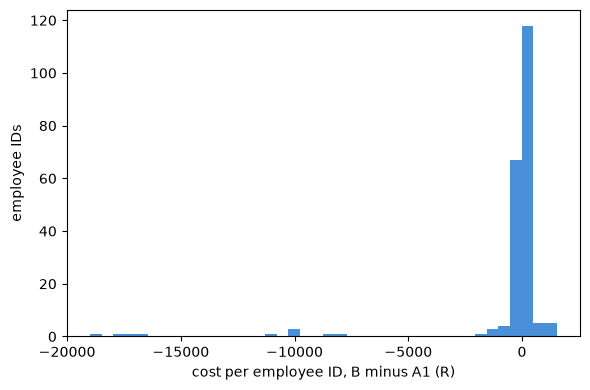

In [12]:
# where does the difference come from? change in 2x hours and in 1.5x hours, in money
d = pd.DataFrame({"hours at 2x": [A1.h_2x.sum(), B.h_2x.sum()], "hours at 1.5x": [A1.h_15x.sum(), B.h_15x.sum()],
                  "premium (R)": [A1.premium.sum(), B.premium.sum()]}, index=["A1", "B"])
d.loc["B - A1"] = d.loc["B"] - d.loc["A1"]
display(d.round(1))
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(emp["diff"], bins=40, color="#4a90d9"); ax.set_xlabel("cost per employee ID, B minus A1 (R)"); ax.set_ylabel("employee IDs")
plt.tight_layout(); plt.show()

## 6. Who earns the overtime and Sunday/holiday premium
Premium pay is everything above the base hourly rate: the extra half for overtime and the extra hundred percent for Sunday and holiday hours. Counted our way (B, with the duplicate people, the lower site on two-site days and overlapping time removed), per person, over the complete weeks. This describes who earns the premium. It is not a finding that anyone did anything wrong.

In [13]:
person = B.groupby("person").agg(hours=("hours", "sum"), h_2x=("h_2x", "sum"), h_15x=("h_15x", "sum"), base_pay=("base_pay", "sum"),
                                    ot_premium=("ot_premium", "sum"), day_premium=("day_premium", "sum"), premium=("premium", "sum"), pay=("pay", "sum"))
person["premium_share_of_pay_%"] = person.premium / person.pay * 100
person["name"] = [name.get(p, ", ".join(name.get(e, e) for e in people.set_index("person_key").employee_ids.get(p, [p]))) for p in person.index]
person = person.sort_values("premium", ascending=False)
n = len(person); top10 = person.head(10); topdec = person.head(int(np.ceil(n * 0.10)))
print("people:", n, "| premium paid: R{:,.0f} of R{:,.0f} total ({:.1f}%)".format(person.premium.sum(), person.pay.sum(), person.premium.sum() / person.pay.sum() * 100))
print("overtime premium R{:,.0f} | Sunday/holiday premium R{:,.0f}".format(person.ot_premium.sum(), person.day_premium.sum()))
print("top 10 people earn {:.1f}% of all premium; top 10% ({}) earn {:.1f}%".format(top10.premium.sum() / person.premium.sum() * 100, len(topdec), topdec.premium.sum() / person.premium.sum() * 100))
display(top10[["name", "hours", "h_15x", "h_2x", "ot_premium", "day_premium", "premium", "premium_share_of_pay_%", "pay"]].round(1))

people: 203 | premium paid: R474,053 of R3,371,826 total (14.1%)
overtime premium R17,562 | Sunday/holiday premium R456,491
top 10 people earn 9.0% of all premium; top 10% (21) earn 17.5%


,name,hours,h_15x,h_2x,ot_premium,day_premium,premium,premium_share_of_pay_%,pay
person,,,,,,,,,
E1061,Pieter Baloyi,456.8,13.0,94.5,368.1,5351.5,5719.6,18.1,31585.4
E1066,Zanele Mavuso,378.0,7.2,83.5,194.2,4473.9,4668.2,18.7,24921.4
E1130,Neo Ndlovu,442.5,12.2,74.2,328.4,3981.3,4309.7,15.4,28036.6
E1198,Andile Jacobs,441.0,27.0,57.2,803.5,3407.5,4211.0,13.8,30459.4
E1056,Sindiswa Khumalo,425.2,5.5,66.5,160.8,3889.6,4050.4,14.0,28923.3
E1071,Sibusiso Mokoena,419.2,16.0,79.0,366.6,3619.8,3986.3,17.2,23196.4
E1041,Yusuf Mavuso,392.8,0.0,90.8,0.0,3931.3,3931.3,18.8,20945.2
E1178,Nokuthula Ngcobo,407.2,2.5,64.5,74.4,3839.0,3913.4,13.9,28153.0
E1122,Dineo Tshabalala,461.0,8.0,107.0,140.5,3757.8,3898.3,19.4,20088.6


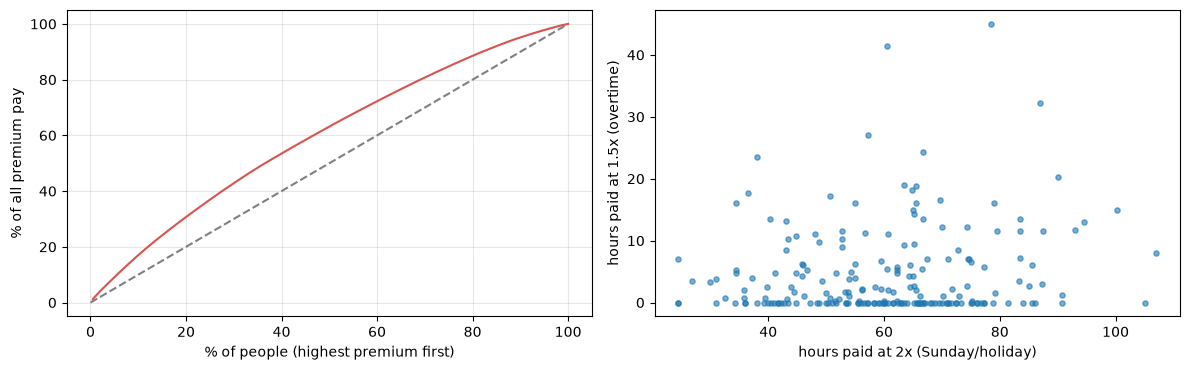

In [14]:
# how concentrated is premium pay? (Lorenz-style curve)
cum = person.premium.sort_values(ascending=False).cumsum() / person.premium.sum()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(np.arange(1, n + 1) / n * 100, cum.values * 100, color="#d9534f"); axes[0].plot([0, 100], [0, 100], "--", color="grey")
axes[0].set_xlabel("% of people (highest premium first)"); axes[0].set_ylabel("% of all premium pay"); axes[0].grid(alpha=.3)
axes[1].scatter(person.h_2x, person.h_15x, s=14, alpha=.6); axes[1].set_xlabel("hours paid at 2x (Sunday/holiday)"); axes[1].set_ylabel("hours paid at 1.5x (overtime)")
plt.tight_layout(); plt.show()

## 7. What breaches cost, and how it connects to the predictions
A breach week is more than 55 hours. The hours beyond 55 are exactly the ones the prediction is meant to help stop. The first part is counted our way (B), so the duplicate people are not in it. The link to the predictions below uses history before the duplicate people are removed, because the model flags them as well.

In [15]:
wk = B.groupby(["person", "week_start"]).agg(hours=("hours", "sum"), over=("h_over55", "sum"), cost_over=("cost_over55", "sum"),
                                                  prem_over=("premium_over55", "sum"), pay=("pay", "sum"))
br = wk[wk.hours > 55]
print("breach weeks (complete weeks):", len(br), "| people with at least one:", br.index.get_level_values(0).nunique())
print("hours beyond 55: {:.0f} | paid R{:,.0f} of which R{:,.0f} is premium".format(br.over.sum(), br.cost_over.sum(), br.prem_over.sum()))
print("share of all pay that went on hours beyond 55: {:.1f}%".format(br.cost_over.sum() / wk.pay.sum() * 100))
print("average beyond-55 cost per breach week: R{:,.0f}".format(br.cost_over.mean()))

weekly_cost = br.groupby(level=1).agg(breach_weeks=("hours", "count"), hours_over=("over", "sum"), cost_over=("cost_over", "sum"))
display(weekly_cost.round(0))

breach weeks (complete weeks): 85 | people with at least one: 57
hours beyond 55: 266 | paid R18,089 of which R8,514 is premium
share of all pay that went on hours beyond 55: 0.5%
average beyond-55 cost per breach week: R213


,breach_weeks,hours_over,cost_over
week_start,,,
2026-06-08,7,14.0,937.0
2026-06-15,5,14.0,839.0
2026-06-22,10,24.0,1718.0
2026-06-29,11,30.0,1929.0
2026-07-06,13,48.0,3113.0
2026-07-13,14,55.0,3645.0
2026-07-20,12,42.0,3006.0
2026-07-27,8,30.0,2209.0
2026-08-03,5,10.0,693.0


In [16]:
# link to the predictions: the people predicted to breach this week and what their past breach weeks cost
pred = pd.read_csv("predictions.csv")
key = employees.merge(pred, on="employee_id")
pk_map = pk.to_dict()
key["person"] = key.employee_id.map(lambda e: pk_map.get(e, e))
flagged = key[key.will_breach == 1].groupby("person").risk_score.max()
# history before the duplicate people are removed (they are flagged by the model, and they are also escalated)
h = price_hours(b_frame(segments, "hours_before_overlap").assign(person=segments.person_key))
wk_h = h.groupby(["person", "week_start"]).agg(hours=("hours", "sum"), cost_over=("cost_over55", "sum"), pay=("pay", "sum"))
hist = wk_h.groupby(level=0).agg(breach_weeks=("hours", lambda x: int((x > 55).sum())), total_pay=("pay", "sum"))
hist["cost_over_55"] = wk_h[wk_h.hours > 55].groupby(level=0).cost_over.sum()
hist = hist.fillna(0)
f = hist.reindex(flagged.index).fillna(0)
print("flagged for this week:", len(flagged), "people, of whom", int(flagged.index.isin(people.person_key).sum()), "are duplicate people (escalated, not paid in B)")
print("they account for {:.1f}% of the breach weeks and {:.1f}% of the cost beyond 55 hours in the past".format(
    f.breach_weeks.sum() / hist.breach_weeks.sum() * 100, f.cost_over_55.sum() / hist.cost_over_55.sum() * 100))
print("past beyond-55 cost of the {} people with a score of 50% or more: R{:,.0f}".format(
    int((flagged >= 0.5).sum()), hist.reindex(flagged[flagged >= 0.5].index).cost_over_55.fillna(0).sum()))
display(f.assign(risk_score=flagged).sort_values("risk_score", ascending=False).head(10).round(2))

flagged for this week: 46 people, of whom 5 are duplicate people (escalated, not paid in B)
they account for 70.2% of the breach weeks and 85.3% of the cost beyond 55 hours in the past
past beyond-55 cost of the 9 people with a score of 50% or more: R16,372


,breach_weeks,total_pay,cost_over_55,risk_score
person,,,,
E1126,7,37440.45,4654.95,0.95
E1099,2,15871.38,879.00,0.88
E1097,6,36842.40,4528.80,0.83
E1035,4,17434.98,1272.23,0.75
E1090,5,21254.06,1635.92,0.72
E1044,3,18587.31,1413.37,0.71
E1138,3,17643.73,339.80,0.70
E1193,5,21565.76,1405.50,0.67
E1132,1,18699.20,242.73,0.57


## Summary
**What the numbers say (complete weeks 8 Jun to 9 Aug, 213 employee IDs).**

| Way of counting | Total cost | Change vs A1 |
|---|---|---|
| A0: summary alone | R3,081,141 | -R431,505 |
| A1: summary hours + Sunday/holiday hours from the shifts | R3,512,646 | |
| + greater-portion rule | R3,520,814 | +R8,168 |
| + duplicate people removed | R3,392,986 | -R119,660 |
| + lower site on two-site days removed | R3,373,110 | -R139,536 |
| **B: + overlapping time removed** | **R3,371,826** | **-R140,820 (-4.0%)** |

- **The client's summary understates what it pays by about R432k (12%).** It has no day detail, so it cannot see the Sunday/holiday premium (R464k) at all.
- **Our counting pays R140.8k (4.0%) less than the client's.** The greater-portion rule adds R8.2k. Removing the 5 duplicate people (10 employee IDs, 2,560 hours) takes out R127.8k. Removing the lower site on two-site days takes out R19.9k and the overlap that is left takes out R1.3k. Together the three checks remove about R149k.
- **Two sites on one day:** 114 person-days (73 people, not counting the duplicate people) have hours at two different sites on the same day. Only the site with more hours is paid, so 451 hours are removed. Most of these shifts overlap in time, so this step also removes almost all of the overlap: only 10 shifts (31 hours) still overlapped afterwards, all at the same site.
- **Duplicate people are most of the saving.** All 10 of their IDs are held back, so B pays nothing to them. This is the cost of paying people the system flags for escalation, not a finding that they were paid wrongly. What happens after review is not modelled.
- **Everyone else:** 203 IDs go from R3,384,818 (A1) to R3,371,826 (B), about -R13.0k. 111 are within R1, 75 cost less and 17 cost more. The biggest changes are about R1.5k a person (up to about 12%), in both directions, because moving a long shift across midnight can add or remove the Sunday premium.
- **The premium is mostly Sundays and holidays, not overtime.** Of R474.1k premium (14.1% of pay) in B, R456.5k is Sunday/holiday and only R17.6k is overtime above 45 hours. About 12,200 hours are paid at 2x. The top 10 people earn 9.0% of all premium and the top 21 (10%) earn 17.5%, so it is spread widely.
- **Breaches are small in money.** In B there are 85 breach weeks (57 people) with 266 hours beyond 55, costing R18.1k (0.5% of pay), about R213 per breach week. Counting the duplicate people as well, as the model does, there are 114 breach weeks. The 46 people flagged this week (5 of them duplicate people) account for 70% of past breach weeks and 85% of the past cost beyond 55 hours.

**What this means.** Our rules pay about R149k less over 9 weeks than the client's way (4.2% of A1), mainly because the system catches duplicate people and two-site days before pay, and the greater-portion rule adds R8k. The summary misses a much larger cost, the Sunday/holiday premium. Stopping breaches themselves saves little in wages (about R2k a week); its value is mainly compliance, and it is concentrated in a few repeat people.

**Limits.** Only complete weeks. Rates are taken as given. The pay rule is our reading of the README (2x on Sundays and holidays, 1.5x above 45 hours, no stacking), not payroll's actual rule. Removing duplicate people assumes both IDs are held back (we cannot tell which is the real person). The two-site rule assumes working at two sites on one day is not allowed, so it also removes the lower site when the two shifts do not overlap in time (13 of the original 123 two-site days) and does not allow for travel. A day is the attributed day (greater-portion rule). When two sites have exactly equal hours, the site that sorts first by site ID is kept. Missing clock-outs are excluded in both methods.